In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from glob import glob

In [2]:
## preprocessing the table data

In [3]:
dataset_table_path = "Houses-dataset-master/Houses Dataset/HousesInfo.txt"

In [4]:
column_names = ["Bedrooms",'Bathroom',"Area","Zipcode","Price"]
data_tab = pd.read_csv(dataset_table_path,sep=" ",names = column_names)

In [5]:
data_tab.head()

,Bedrooms,Bathroom,Area,Zipcode,Price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


In [6]:
data_tab.isna().sum()

Bedrooms    0
Bathroom    0
Area        0
Zipcode     0
Price       0
dtype: int64

In [7]:
data_tab.Zipcode.unique().shape

(49,)

In [8]:
np.unique(data_tab.Zipcode, return_counts=True)

(array([36372, 60002, 60016, 60046, 62025, 62034, 62088, 62214, 62234,
        62249, 81418, 81521, 81524, 85255, 85262, 85266, 85331, 85377,
        90038, 90211, 90265, 90803, 91752, 91901, 91915, 92021, 92040,
        92253, 92276, 92543, 92677, 92692, 92802, 92880, 93105, 93111,
        93314, 93446, 93510, 93720, 93924, 94501, 94531, 94565, 94568,
        95008, 95220, 96019, 98021]),
 array([  1,   3,   2,   1,   2,   1,   1,   4,   7,   1,   2,   1,  11,
         12,   9,  11,   1,   3,   1,   1,   1,   1,   3,  32,   1,  11,
          1,   2, 100,   1,  26,   2,   9,  49,   1,  11,   1,  54,  60,
          1,   1,  41,  22,   1,   1,   1,  10,  12,   4]))

In [9]:
## if there are only a few samples for a zipcode it does not make sence to consider them for training!
zip_count = np.unique(data_tab.Zipcode, return_counts=True)[1]
zip_count[zip_count>= 9]

array([ 11,  12,   9,  11,  32,  11, 100,  26,   9,  49,  11,  54,  60,
        41,  22,  10,  12])

In [10]:
zipcode = np.unique(data_tab.Zipcode, return_counts=True)
for i,j in zip(zipcode[0],zipcode[1]):
    if j < 9 :
        data_tab.loc[data_tab.Zipcode==i,'Zipcode'] = 0

In [11]:
ohe_encode = OneHotEncoder()
zipcode_encode = ohe_encode.fit_transform(data_tab.Zipcode.values.reshape(-1,1)).toarray()

In [12]:
scaler = StandardScaler()
data_tab_scaled = scaler.fit_transform(data_tab[["Bedrooms","Bathroom","Area"]])

In [13]:
max_price = data_tab.Price.max()
price = data_tab.Price / max_price

In [14]:
data_tab = np.concatenate([data_tab_scaled,zipcode_encode],axis=1)

In [15]:
data_tab .shape

(535, 21)

In [16]:
## preprocessing the image data
## there are four pictures for each sample there are differenet ways to use them for training
## we can merge them as single image (the arrangement of the images should be same for all the samples)use sort()!
## 4 (64 * 64 * 3) -----> 128 * 128 * 3
## or we can stack them in depth ----->  64 * 64 * 12

In [17]:
img_data_path = "Houses-dataset-master/Houses Dataset"

In [18]:
img_path = glob(img_data_path + "/1_*.jpg")

In [19]:
img_path

['Houses-dataset-master/Houses Dataset\\1_bathroom.jpg',
 'Houses-dataset-master/Houses Dataset\\1_bedroom.jpg',
 'Houses-dataset-master/Houses Dataset\\1_frontal.jpg',
 'Houses-dataset-master/Houses Dataset\\1_kitchen.jpg']

In [20]:
data_img = []
for i in range(1,len(data_tab)+1):
    img_path = glob(img_data_path + f"/{i}_*.jpg")
    img_path.sort()
    img_list = []
    for path in img_path:
        img = cv2.imread(path)
        img = cv2.resize(img,(64,64))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img_list.append(img)

    img_combo = np.dstack(img_list)
    data_img.append(img_combo)

data_img = np.array(data_img) / 255

In [21]:
data_img.shape

(535, 64, 64, 12)

In [22]:
X_tab_train = data_tab[:435]
X_tab_test =  data_tab[435:]

X_img_train = data_img[:435]
X_img_test = data_img[435:]

y_train = price[:435]
y_test = price[435:]

In [23]:
## preparing the model architecture

In [29]:
import tensorflow as tf
from tensorflow.keras.layers import Input,Flatten,Conv2D,MaxPool2D,Dropout,Dense,Concatenate
from tensorflow.keras.models import Model

In [25]:
input_layer_tab = Input(shape=(21,))
dense_layer1_tab = Dense(units=128,activation="relu")(input_layer_tab)
dp_layer1_tab = Dropout(0.4)(dense_layer1_tab)
dense_layer2_tab = Dense(units=128,activation="relu")(dp_layer1_tab)

input_layer_img = Input(shape=(64,64,12))
conv_layer1_img = Conv2D(16,(3,3),activation="relu")(input_layer_img)
dp_layer1_img = Dropout(0.25)(conv_layer1_img)
maxpool_layer1_img = MaxPool2D()(dp_layer1_img)
conv_layer2_img = Conv2D(32,(3,3),activation="relu")(maxpool_layer1_img)
dp_layer2_img = Dropout(0.25)(conv_layer2_img)
maxpool_layer2_img = MaxPool2D()(dp_layer2_img)
flatten = Flatten()(maxpool_layer2_img)

concat = Concatenate()([dense_layer2_tab,flatten])

output_layer1 = Dense(units=64,activation="relu")(concat)
dp_layer1 = Dropout(0.25)(output_layer1)
output_layer2 = Dense(units=1,activation="linear")(dp_layer1)


model = Model(inputs=[input_layer_tab,input_layer_img],outputs = [output_layer2])

In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 64, 64, 12)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 62, 62, 16)        │           1,744 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 62, 62, 16)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 31, 31, 16)        │               0 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer (InputLayer)      │ (None, 21)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 29, 29, 32)        │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │           2,816 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 29, 29, 32)        │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 14, 14, 32)        │               0 │ dropout_2[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 128)               │          16,512 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 6272)              │               0 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 6400)              │               0 │ dense_1[0][0],             │
│                               │                           │                 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │         409,664 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 64)                │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              65 │ dropout_3[0][0]            │
└───────────────────────────────┴───────────────────────────┴───────────────

 Total params: 435,441 (1.66 MB)

 Trainable params: 435,441 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.utils import plot_model

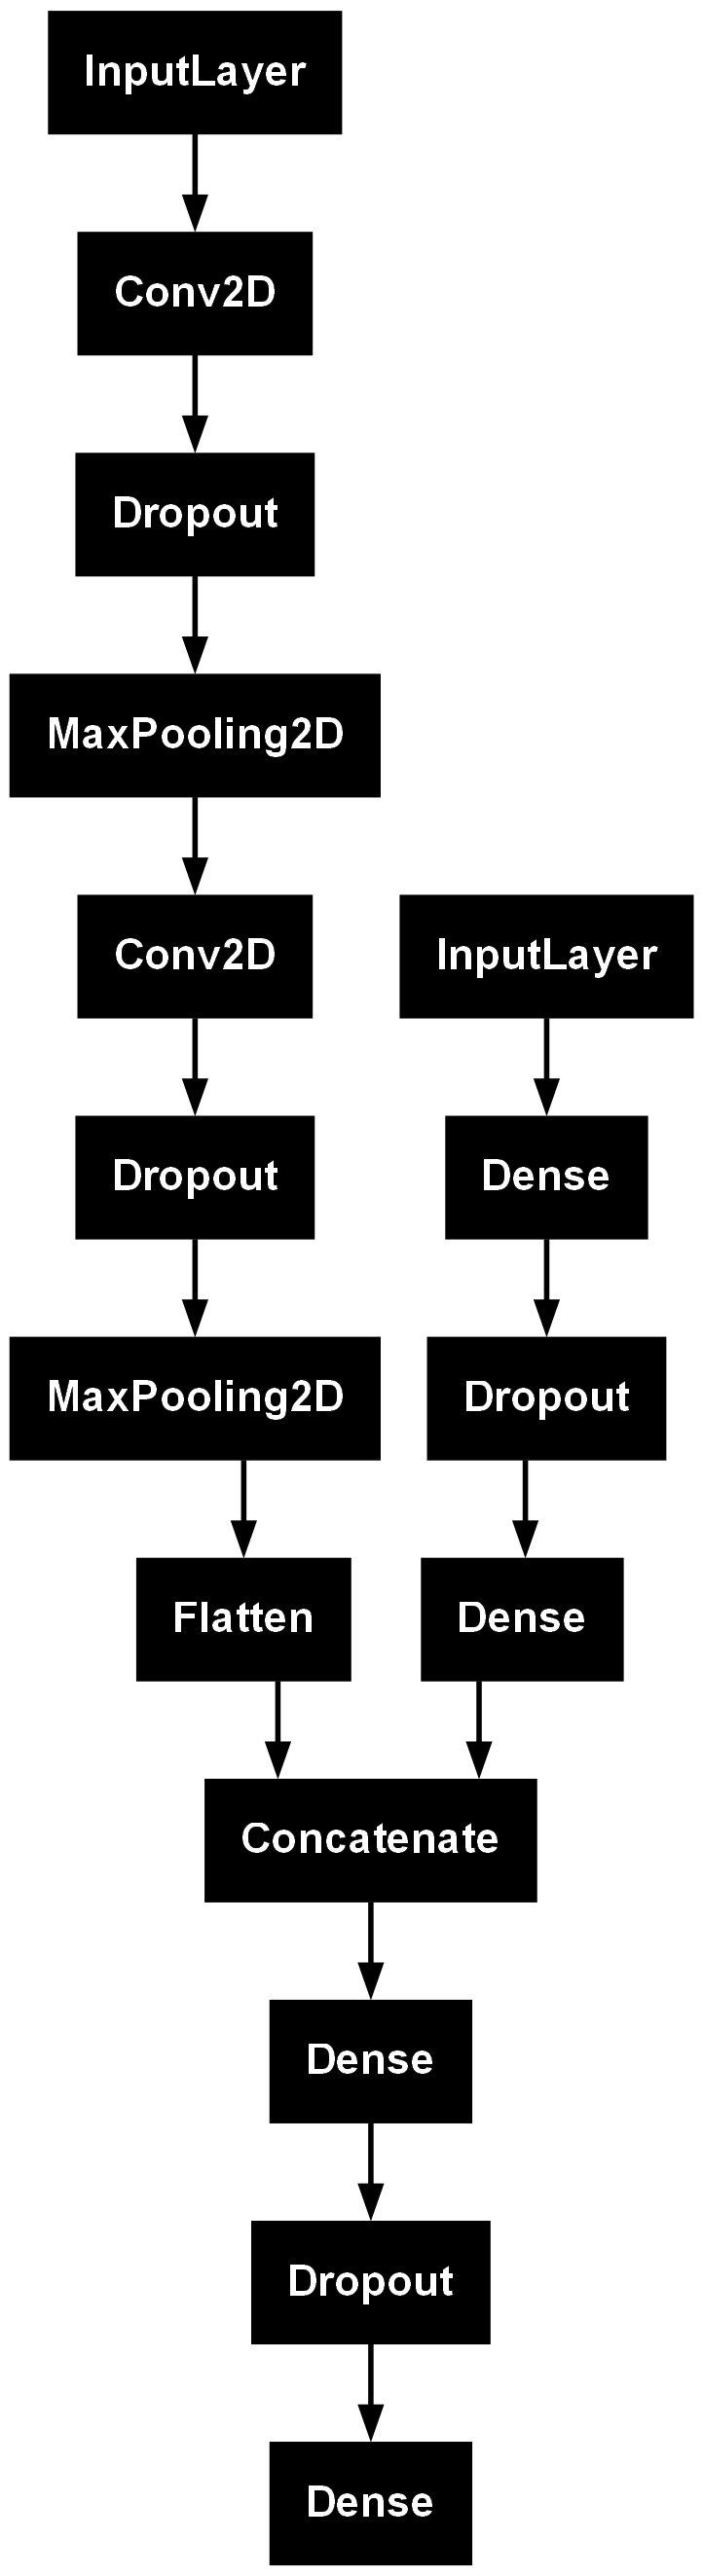

In [28]:
plot_model(model)

In [30]:
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.MeanAbsoluteError()
## we can also use meansquarederror!
model.compile(optimizer=opt,loss=loss)

In [32]:
model.fit([X_tab_train,X_img_train],y_train,epochs= 100, validation_data = [[X_tab_test,X_img_test],y_test],verbose=2)

Epoch 1/100
14/14 - 3s - 206ms/step - loss: 0.7204 - val_loss: 0.0798
Epoch 2/100
14/14 - 1s - 36ms/step - loss: 0.0681 - val_loss: 0.0411
Epoch 3/100
14/14 - 1s - 38ms/step - loss: 0.0497 - val_loss: 0.0370
Epoch 4/100
14/14 - 1s - 38ms/step - loss: 0.0451 - val_loss: 0.0370
Epoch 5/100
14/14 - 1s - 38ms/step - loss: 0.0409 - val_loss: 0.0418
Epoch 6/100
14/14 - 0s - 35ms/step - loss: 0.0360 - val_loss: 0.0369
Epoch 7/100
14/14 - 0s - 30ms/step - loss: 0.0352 - val_loss: 0.0335
Epoch 8/100
14/14 - 0s - 31ms/step - loss: 0.0310 - val_loss: 0.0356
Epoch 9/100
14/14 - 0s - 32ms/step - loss: 0.0311 - val_loss: 0.0382
Epoch 10/100
14/14 - 0s - 30ms/step - loss: 0.0293 - val_loss: 0.0311
Epoch 11/100
14/14 - 0s - 31ms/step - loss: 0.0295 - val_loss: 0.0328
Epoch 12/100
14/14 - 0s - 31ms/step - loss: 0.0292 - val_loss: 0.0313
Epoch 13/100
14/14 - 0s - 30ms/step - loss: 0.0276 - val_loss: 0.0310
Epoch 14/100
14/14 - 0s - 30ms/step - loss: 0.0262 - val_loss: 0.0332
Epoch 15/100
14/14 - 0s - 31

In [36]:
### create a single image of four image

In [33]:
data_img = []
for i in range(1,len(data_tab)+1):
    img_path = glob(img_data_path + f"/{i}_*.jpg")
    img_path.sort()
    img_list = []
    for path in img_path:
        img = cv2.imread(path)
        img = cv2.resize(img,(64,64))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img_list.append(img)

    img_combo_v_1 = np.vstack(img_list[:2])
    img_combo_v_2 = np.vstack(img_list[2:])
    img_combo = np.hstack([img_combo_v_1,img_combo_v_2])
    break

In [34]:
img_combo.shape

(128, 128, 3)

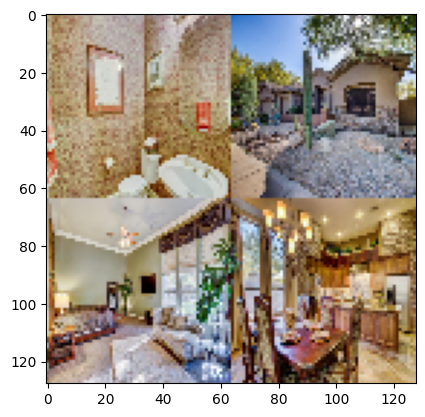

In [35]:
plt.imshow(img_combo)

In [ ]:
## the input shape of model should be changed to (128,128,3)